<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK05/diabetes_DL_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv

In [ ]:
# diabetes.csv 파일을 바탕으로 딥러닝(Deep Learning) classification 실습

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv'

# CSV 파일을 DataFrame 형태로 읽기
df = pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# 데이터 전체 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# 컬렴명 확인
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

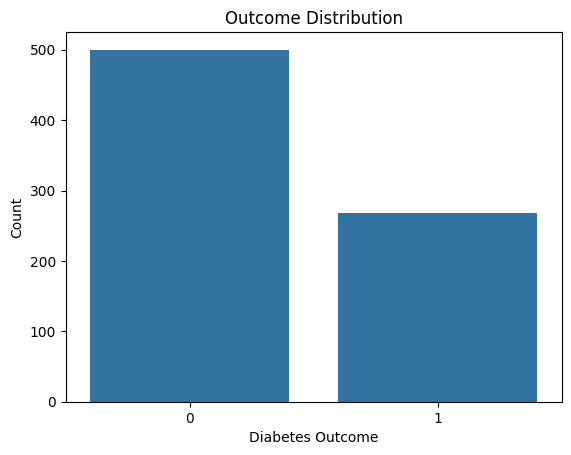

In [ ]:
# 정답 데이터(Outcome) 분포 확인
sns.countplot(data=df, x='Outcome')
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.title("Outcome Distribution")
plt.show()

In [ ]:
# 레이블 개수 확인 (숫자)
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# 결측치 확인
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# 정답 데이터(y) 설정
# Outcome 컬럼이 분류해야 할 목표값(레이블)이다.
y = df['Outcome']
print(y.value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# 원-핫 인코딩
# 출력층 형태와 정답 데이터 형태를 맞추기 위해 원-핫 인코딩을 한다.
# 다중 분류 문제이므로 각 클래스를 0과 1로 이루어진 벡터 형태로 변환한다.
# 예: 클래스 1 -> [1,0,0], 클래스 2 -> [0,1,0], 클래스 3 -> [0,0,1]
# 딥러닝 모델의 출력층이 보통 각 클래스별 확률을 여러 개 출력하기 때문이다.
# 예시) [0.1, 0.8, 0.1]
Y = pd.get_dummies(y).values

In [ ]:
# 입력 데이터(X) 생성
# Outcome을 예측해야 하므로 Outcome 컬럼은 제외한다.
X = df.drop('Outcome', axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
# 딥러닝 입력을 위해 DataFrame을 Numpy 배열로 변환
X = X.values

In [ ]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
# 표준화는 데이터의 각 feature를 비슷한 크기 범위로 맞추는 작업이다.
# 각 feature의 평균을 0, 표준편차를 1에 가깝게 맞춰 학습 성능을 높인다.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

# 학습용 데이터와 테스트용 데이터 분리
# test_size=0.2 -> 전체 데이터의 20%를 테스트용으로 사용
# y 대신 원-핫 인코딩된 Y를 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0    # y를 Y로 변경
)

In [ ]:
# 딥러닝 모델 생성
# 입력층 -> 은닉층1 -> Dropout -> 은닉층2 -> 출력층 구조
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),  # X.shape[1] = 입력 feature의 개수
    layers.Dropout(0.3),     # 과적합 방지를 위해 일부 뉴런을 무작위로 비활성화
    layers.Dense(32, activation='relu'),
    layers.Dense(Y.shape[1], activation='softmax')    # Y.shape[1] = 클래스 개수, 클래스 수만큼 출력 노드 설정
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 컴파일
# optimizer='adam' : 가중치 최적화 방법
# loss='categorical_crossentropy' : 원-핫 인코딩된 다중분류 손실 함수
# metrics=['accuracy'] : 정확도를 평가지표로 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # one-hot이면 categorical_crossentropy
    metrics=['accuracy']
)

In [ ]:
# 모델 학습
# validation_split=0.2 : 학습 데이터 중 20%를 검증용으로 사용
# epochs=50 : 전체 데이터를 50번 반복 학습
# batch_size=16 : 한 번에 16개씩 나누어 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6069 - loss: 0.6732 - val_accuracy: 0.7317 - val_loss: 0.5654
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7088 - loss: 0.5779 - val_accuracy: 0.7967 - val_loss: 0.5105
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7332 - loss: 0.5288 - val_accuracy: 0.7886 - val_loss: 0.4845
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7475 - loss: 0.5116 - val_accuracy: 0.7724 - val_loss: 0.4759
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7556 - loss: 0.4978 - val_accuracy: 0.7724 - val_loss: 0.4806
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7739 - loss: 0.4759 - val_accuracy: 0.7805 - val_loss: 0.4814
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7637 - loss: 0.4782 - val_accuracy: 0.7805 - val_loss: 0.4786
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4591 - val_accuracy: 0.7886 - val_loss

In [ ]:
# 테스트 데이터 예측
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
# 원-핫 인코딩 -> 클래스 번호 변환
# 예: [0,1,0] -> 1
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

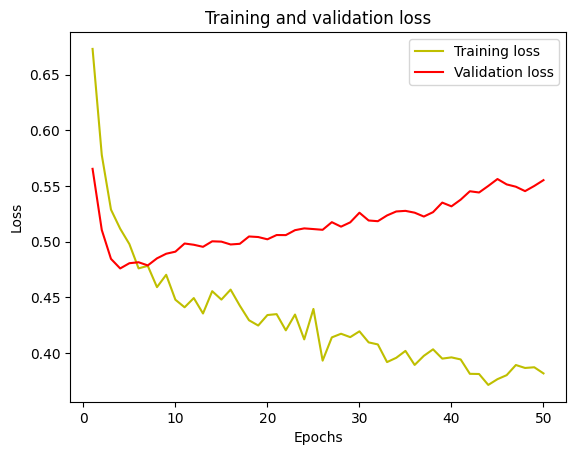

In [ ]:
# Loss 그래프에 사용할 값 추출
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Loss 그래프
# 학습 손실과 검증 손실의 변화를 통해 모델 학습 상태를 확인
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

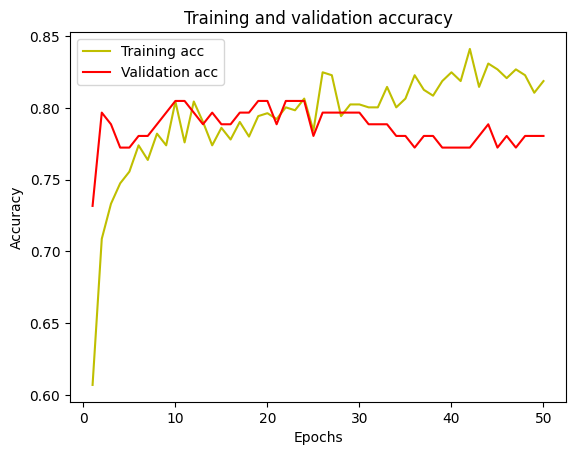

In [ ]:
# Accuracy 그래프에 사용할 값 추출
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Accuracy 그래프
# 학습 정확도와 검증 정확도의 변화를 통해 모델 성능을 확인
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 분류 성능 평가
# classification_report : precision, recall, f1-score 출력
# confusion_matrix : 실제값과 예측값 비교표 출력
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_class, y_pred_class))
print(confusion_matrix(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       107
           1       0.66      0.66      0.66        47

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.79      0.79      0.79       154

[[91 16]
 [16 31]]
